# ÉCONOMÉTRIE

https://www.onisr.securite-routiere.gouv.fr/dataviz

In [66]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency
from scipy.stats import jarque_bera
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.pylab import rcParams
from scipy.stats import kendalltau, spearmanr, chi2_contingency, kruskal, wilcoxon, mannwhitneyu
from scipy.stats.contingency import association
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from prince import CA, MCA, FAMD, PCA
from scipy.cluster.hierarchy import dendrogram, linkage
rcParams['figure.figsize'] = 5,3
import statsmodels.api as sm
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve,accuracy_score)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay

## Importation des bases 

In [2]:
os.getcwd()

'/Users/gerard/Desktop/DU_BIGDATA/projet_tuteures/Apprentissage supervisée/paramétrique_économétrie'

In [3]:
# Chargement des bases de caractéristiques (X)
df = pd.read_csv("base_complete_2021.csv", sep=';')
df.head()

,Num_Acc,jour,mois,an,hrmn,lum,com,agg,int,atm,...,etatp,num_veh_y,senc,catv,obs,obsm,choc,manv,motor,occutc
0,202100037733,28,5,2021,14:15,1,CC_97407,2,2,1,...,-1,B01,3,1,0,2,8,1,5,0
1,202100049382,2,3,2021,10:59,1,CC_63113,2,1,1,...,-1,A01,1,10,0,2,1,2,1,0
2,202100038891,20,5,2021,16:50,1,CC_88160,2,2,1,...,-1,A01,1,7,0,2,1,1,1,0
3,202100028616,14,7,2021,19:45,1,CC_80021,2,1,1,...,-1,A01,0,7,0,2,1,15,1,0
4,202100033509,17,6,2021,23:40,3,CC_13214,2,1,1,...,-1,A01,2,7,4,5,1,26,1,0


## Fonctions utiles

In [6]:
def analyse_df(df):

    for var in df.columns:
        
        print("\n" + "="*50)
        print(f"ANALYSE DE LA VARIABLE : {var}")
        print("="*50)

        print(f"Type : {df[var].dtype}")
        print(f"Valeurs manquantes : {df[var].isna().sum()}")

        # Variables numériques
        if pd.api.types.is_numeric_dtype(df[var]):

            print("\nStatistiques descriptives :")
            print(df[var].describe())

        # Variables catégorielles
        else:

            counts = df[var].value_counts()

            print("\nTop modalités :")
            print(counts.head(10))

## Analyse descriptive des données 

In [7]:
df.info()
df.isna().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56525 entries, 0 to 56524
Data columns (total 54 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Num_Acc      56525 non-null  int64  
 1   jour         56525 non-null  int64  
 2   mois         56525 non-null  int64  
 3   an           56525 non-null  int64  
 4   hrmn         56525 non-null  object 
 5   lum          56525 non-null  int64  
 6   com          56525 non-null  object 
 7   agg          56525 non-null  int64  
 8   int          56525 non-null  int64  
 9   atm          56525 non-null  int64  
 10  col          56525 non-null  int64  
 11  adr          55952 non-null  object 
 12  lat          56525 non-null  object 
 13  long         56525 non-null  object 
 14  dep          56525 non-null  object 
 15  catr         56525 non-null  int64  
 16  voie         52117 non-null  object 
 17  v1           56525 non-null  int64  
 18  v2           56525 non-null  object 
 19  circ

np.int64(0)

### Analyse univariée

Visualiser la colonne **grav** brute (avec les codes 1, 2, 3, 4) est difficile à interpréter pour un lecteur.

Je définie la colonne **grav** en une colonne **target** (**0 = Léger, 1 = Grave**), ce qui me permet de voir mon premier graphique avec la proportion réelle du risque dans ton étude.

C'est le point de départ de mon argumentation : "Dans la base, X% des accidents sont **graves** ou X% **moins grave**".

In [16]:
# 1 = Indemne, 2 = Tué, 3 = Blessé hospitalisé, 4 = Blessé léger
# On regroupe 2 et 3 pour définir la gravité (Grave)
df['target'] = df['grav'].apply(lambda x: 1 if x in [2, 3] else 0)

# Vérification de la création
print(df['target'].value_counts())

target
0    44688
1    11837
Name: count, dtype: int64


In [17]:
# Sélection des variables pertinentes pour l'étude (on écarte les IDs et adresses)
cols_etude = ['target', 'lum', 'agg', 'atm', 'col', 'catr', 'surf', 'catv', 'sexe', 'trajet', 'motor']
df_analyse = df[cols_etude]

In [19]:
# Utilisation de ta fonction sur les variables clés
analyse_df(df_analyse)


ANALYSE DE LA VARIABLE : target
Type : int64
Valeurs manquantes : 0

Statistiques descriptives :
count    56525.000000
mean         0.209412
std          0.406892
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: target, dtype: float64

ANALYSE DE LA VARIABLE : lum
Type : int64
Valeurs manquantes : 0

Statistiques descriptives :
count    56525.000000
mean         1.835418
std          1.437601
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          5.000000
Name: lum, dtype: float64

ANALYSE DE LA VARIABLE : agg
Type : int64
Valeurs manquantes : 0

Statistiques descriptives :
count    56525.000000
mean         1.642583
std          0.479243
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          2.000000
Name: agg, dtype: float64

ANALYSE DE LA VARIABLE : atm
Type : int64
Valeurs manquantes : 0

Statistiques descriptives :
count   

## Analyse bivariée

**Relation : target vs cols_etude (variables qui influences les accidents)**

**#A8DADC (Bleu clair) :** Représente généralement la classe **0 (Léger)**.

**#E63946 (Rouge) :** Représente la classe **1 (Grave)**, donc Le rouge attire immédiatement l'œil sur les situations les plus dangereuses.

**kind='bar'** définit le type de graphique, cela permet de comparer des catégories (ex: les types de météo atm ou de routes catr).

**stacked=True** cela permet d'empiler les catégories de la **target** les unes sur les autres au lieu de les mettre côte à côte. Puisque j'ai normalisé les données (normalize='index' dans le crosstab), chaque barre fait exactement 100% de haut. Cela nous montre d'un coup d'œil la proportion relative de gravité pour chaque modalité.

**ax=plt.gca()** Cela signifie "Get Current Axis". Ce qui demande à Pandas de dessiner le graphique sur la figure Matplotlib qui est déjà ouverte et permet de garder le contrôle sur la personnalisation (titres, étiquettes) avant d'afficher le résultat final.


══════════════════════════════════════════════════
════════ ANALYSE BIVARIÉE : LUM vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
lum                 
1       80.20  19.80
2       77.01  22.99
3       64.49  35.51
4       78.32  21.68
5       83.51  16.49


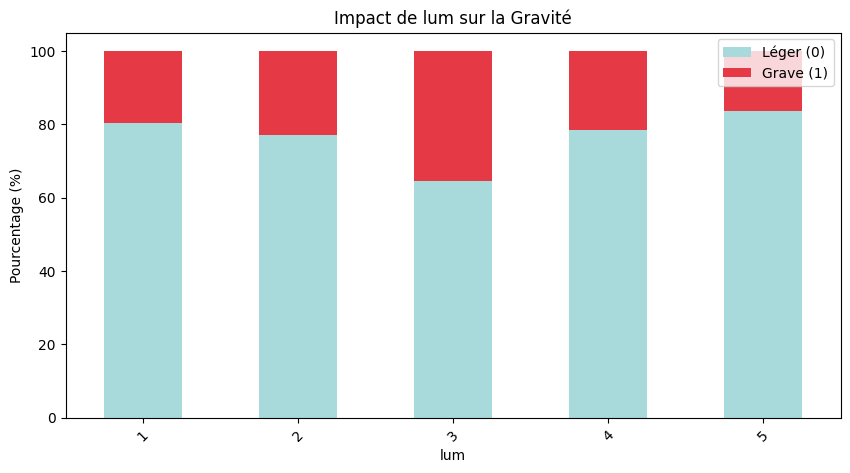


══════════════════════════════════════════════════
════════ ANALYSE BIVARIÉE : AGG vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
agg                 
1       67.84  32.16
2       85.30  14.70


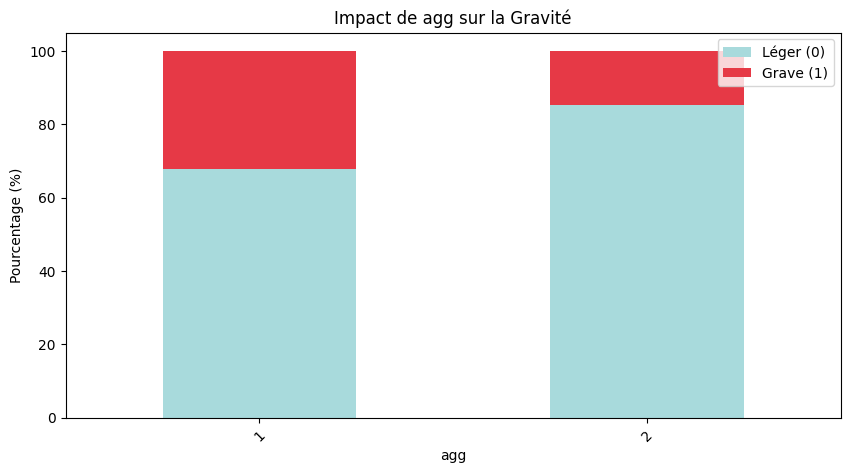


══════════════════════════════════════════════════
════════ ANALYSE BIVARIÉE : ATM vs TARGET ════════

Pourcentage de gravité par modalité :
target       0      1
atm                  
-1      100.00   0.00
 1       78.85  21.15
 2       82.57  17.43
 3       80.42  19.58
 4       80.25  19.75
 5       66.17  33.83
 6       66.95  33.05
 7       75.15  24.85
 8       79.41  20.59
 9       64.16  35.84


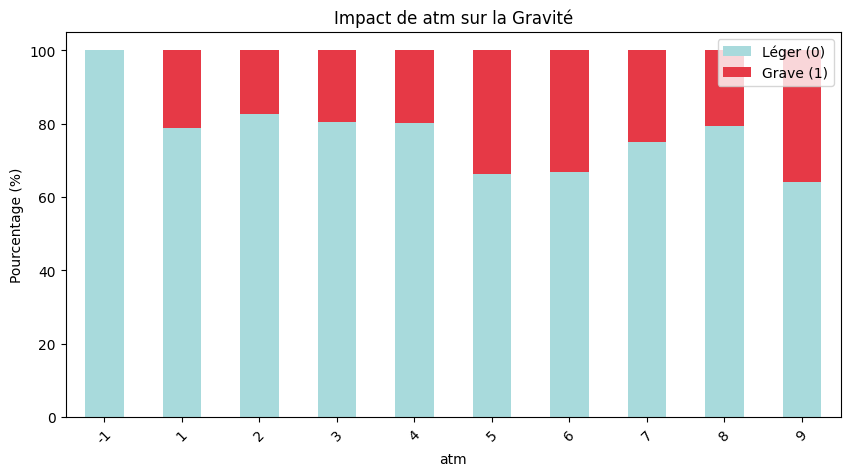


══════════════════════════════════════════════════
════════ ANALYSE BIVARIÉE : COL vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
col                 
-1      60.00  40.00
 1      73.15  26.85
 2      90.56   9.44
 3      87.18  12.82
 4      94.69   5.31
 5      86.94  13.06
 6      70.86  29.14
 7      59.67  40.33


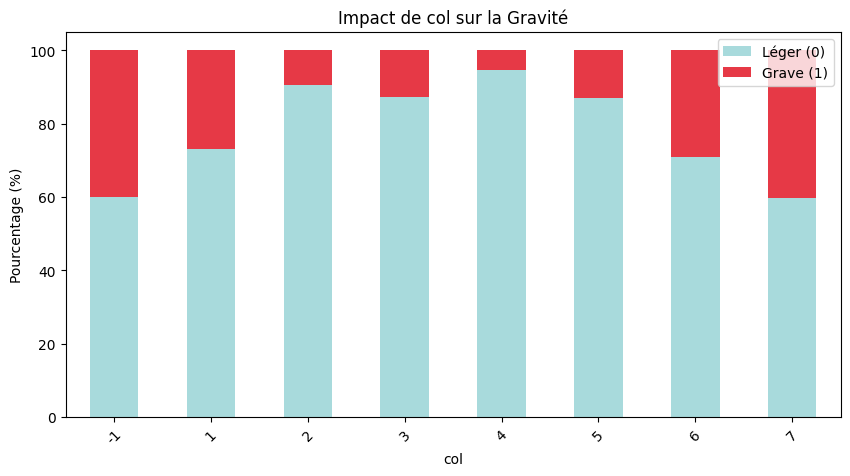


══════════════════════════════════════════════════
═══════ ANALYSE BIVARIÉE : CATR vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
catr                
1       88.38  11.62
2       77.47  22.53
3       68.30  31.70
4       86.31  13.69
5       69.84  30.16
6       79.49  20.51
7       81.16  18.84
9       70.22  29.78


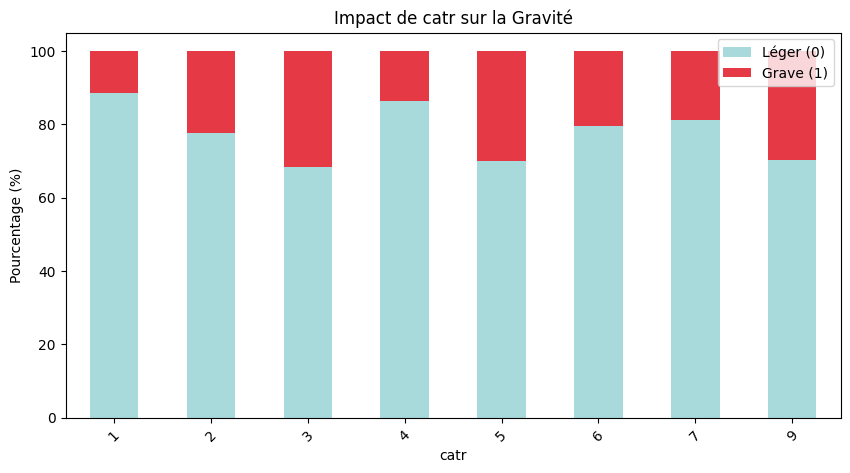


══════════════════════════════════════════════════
═══════ ANALYSE BIVARIÉE : SURF vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
surf                
-1      78.57  21.43
 1      78.98  21.02
 2      80.78  19.22
 3      69.33  30.67
 4      78.26  21.74
 5      81.63  18.37
 6      42.86  57.14
 7      61.62  38.38
 8      81.69  18.31
 9      56.91  43.09


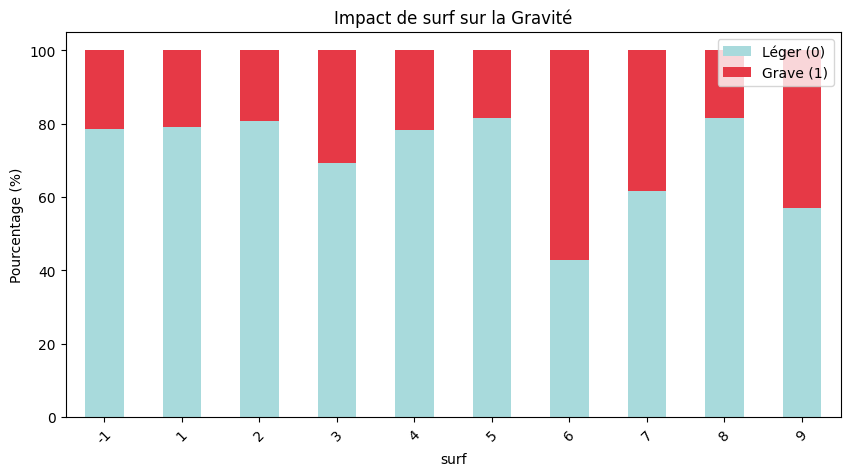


══════════════════════════════════════════════════
═══════ ANALYSE BIVARIÉE : CATV vs TARGET ════════

Pourcentage de gravité par modalité :
target      0      1
catv                
-1      50.00  50.00
 0      86.90  13.10
 1      71.25  28.75
 2      59.30  40.70
 3      81.76  18.24
 7      83.77  16.23
 10     88.40  11.60
 13     93.37   6.63
 14     88.61  11.39
 15     85.59  14.41
 16     75.00  25.00
 17     82.75  17.25
 20     76.79  23.21
 21     73.97  26.03
 30     83.34  16.66
 31     61.41  38.59
 32     76.79  23.21
 33     53.79  46.21
 34     73.88  26.12
 35     33.33  66.67
 36     32.08  67.92
 37     93.37   6.63
 38     86.52  13.48
 39     68.97  31.03
 40     86.90  13.10
 41     80.00  20.00
 42     66.67  33.33
 43     75.64  24.36
 50     83.67  16.33
 60     85.27  14.73
 80     72.62  27.38
 99     79.54  20.46


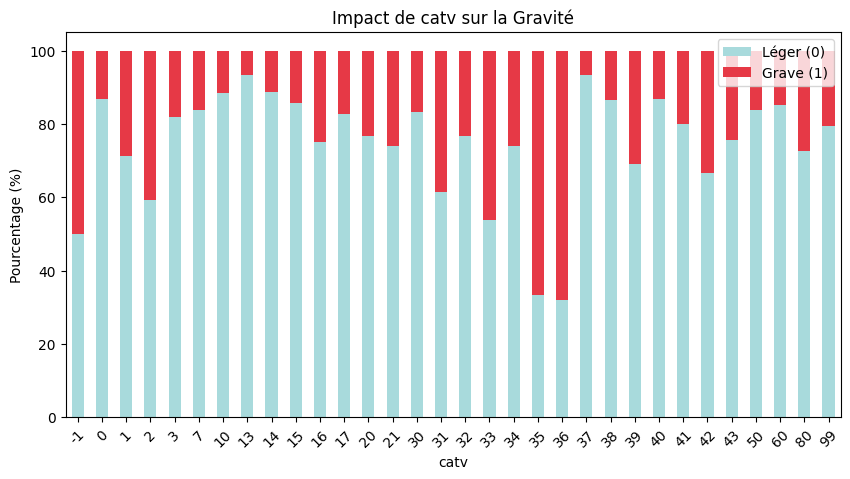


══════════════════════════════════════════════════
═══════ ANALYSE BIVARIÉE : SEXE vs TARGET ════════

Pourcentage de gravité par modalité :
target       0      1
sexe                 
-1      100.00   0.00
 1       76.76  23.24
 2       82.85  17.15
 3       50.00  50.00


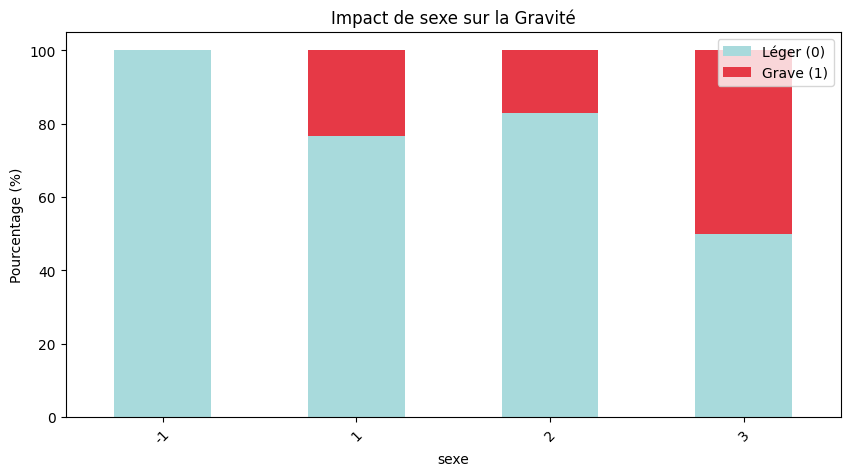


══════════════════════════════════════════════════
══════ ANALYSE BIVARIÉE : TRAJET vs TARGET ═══════

Pourcentage de gravité par modalité :
target      0      1
trajet              
-1      99.00   1.00
 0      82.06  17.94
 1      81.80  18.20
 2      81.83  18.17
 3      73.24  26.76
 4      91.36   8.64
 5      70.32  29.68
 9      82.99  17.01


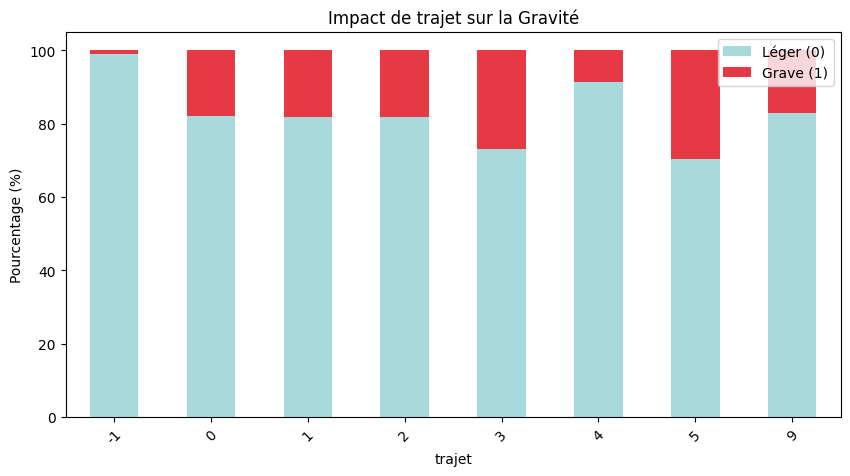


══════════════════════════════════════════════════
═══════ ANALYSE BIVARIÉE : MOTOR vs TARGET ═══════

Pourcentage de gravité par modalité :
target      0      1
motor               
-1      87.25  12.75
 0      85.42  14.58
 1      78.70  21.30
 2      91.06   8.94
 3      83.88  16.12
 4      76.47  23.53
 5      71.88  28.12
 6      75.47  24.53


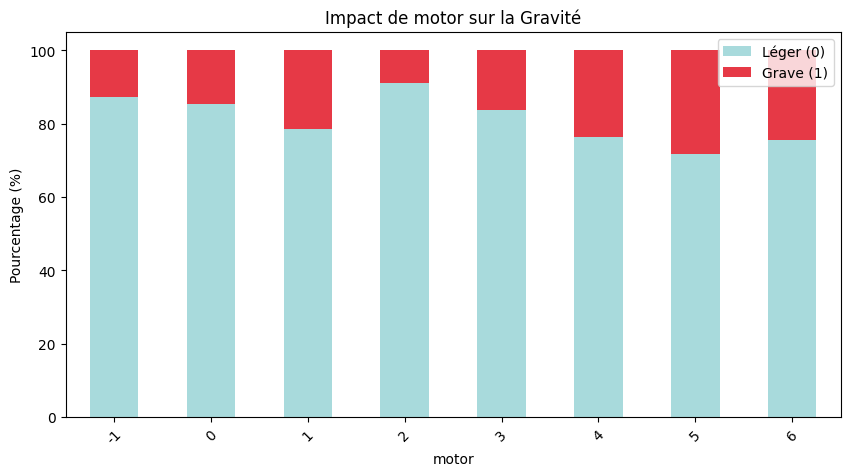

In [21]:
def analyse_bivariee(df, target_col):
    # On itère sur toutes les colonnes sauf la target
    for var in df.columns:
        if var == target_col:
            continue
            
        print("\n" + "═"*50)
        print(f" ANALYSE BIVARIÉE : {var.upper()} vs {target_col.upper()} ".center(50, "═"))
        
        # Tableau de croisement (Crosstab) en pourcentage
        ct = pd.crosstab(df[var], df[target_col], normalize='index') * 100
        print("\nPourcentage de gravité par modalité :")
        print(ct.round(2))
        
        # Visualisation
        plt.figure(figsize=(10, 5))
        ct.plot(kind='bar', stacked=True, color=['#A8DADC', '#E63946'], ax=plt.gca())
        plt.title(f"Impact de {var} sur la Gravité")
        plt.ylabel("Pourcentage (%)")
        plt.legend(["Léger (0)", "Grave (1)"], loc='upper right')
        plt.xticks(rotation=45)
        plt.show()

# Lancement de l'analyse bivariée
analyse_bivariee(df_analyse, 'target')

**Le Test du Chi-deux (χ 
2
 )**

Il permet de tester l'hypothèse nulle (**H0**
​	
 ) : "La variable X et la Target sont indépendantes". Si la p-value < 0.05, on rejette **H0**: 
​    
et on conclut que la variable a une influence réelle sur la gravité.

In [32]:
# 1. Liste pour stocker les scores du Chi-deux
resultats_khi2 = []

for col in cols_etude:
    if col != 'target':
        # Création de la table de contingence
        contingency_table = pd.crosstab(df[col], df['target'])
        
        # Calcul du Chi-deux
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        
        resultats_khi2.append({
            'Variable': col, 
            'Stat_Chi2': chi2, 
            'p-value': p
        })

# 2. Transformation en DataFrame
df_khi2 = pd.DataFrame(resultats_khi2)

# 3. Tri du plus significatif au moins significatif (p-value la plus petite en haut)
df_khi2 = df_khi2.sort_values(by='p-value', ascending=True)

# Affichage formaté (pour éviter les notations scientifiques illisibles)
pd.options.display.float_format = '{:.5f}'.format
print("Résultats du Test du Chi-deux (Significativité) :")
print(df_khi2.reset_index(drop=True))

Résultats du Test du Chi-deux (Significativité) :
  Variable  Stat_Chi2  p-value
0      agg 2390.62995  0.00000
1      col 3749.67420  0.00000
2     catr 2490.25820  0.00000
3     catv 3687.09966  0.00000
4   trajet 1916.79935  0.00000
5      lum  776.00510  0.00000
6     sexe  616.07567  0.00000
7    motor  278.57008  0.00000
8     surf  210.00460  0.00000
9      atm  148.89109  0.00000


**Commentaire :**


**Le V de Cramer (Force de la relation) :**

La **p-value** dit si il y a une relation, mais le **V de Cramer** dit si elle est forte.

**0.1 :** Relation faible.

**0.3 :** Relation moyenne.

**> 0.5 :** Relation forte (très bon prédicteur pour ton modèle).

In [31]:
# 1. On prépare une liste pour stocker les résultats
resultats_cramer = []

# 2. On boucle sur toutes les variables de ta liste (sauf la cible elle-même)
for col in cols_etude:
    if col != 'target':
        # On calcule le score avec ta fonction
        score = cramers_v(df[col], df['target'])
        
        # On ajoute le résultat dans la liste
        resultats_cramer.append({'Variable': col, 'V_de_Cramer': score})

# 3. On transforme en DataFrame pour un affichage propre
df_scores = pd.DataFrame(resultats_cramer)

# 4. On trie du plus influent au moins influent
df_scores = df_scores.sort_values(by='V_de_Cramer', ascending=False)

# Tri explicite du plus grand au plus petit (ascending=False)
df_scores_trie = df_scores.sort_values(by='V_de_Cramer', ascending=False)

# Affichage avec un bel index réinitialisé
print(df_scores_trie.reset_index(drop=True))

  Variable  V_de_Cramer
0      col     0.257559
1     catv     0.255401
2     catr     0.209895
3      agg     0.205653
4   trajet     0.184148
5      lum     0.117169
6     sexe     0.104399
7    motor     0.070202
8     surf     0.060953
9      atm     0.051323


**Hiérarchie et Significativité des Variables (Test du χ 
2
  et V de Cramer) :**

In [33]:
df_final_analyse = pd.merge(df_scores, df_khi2, on='Variable')
df_final_analyse['Decision'] = df_final_analyse['p-value'].apply(lambda x: 'Conserver' if x < 0.05 else 'Écarter')

print(df_final_analyse.sort_values(by='V_de_Cramer', ascending=False))

  Variable  V_de_Cramer  Stat_Chi2  p-value   Decision
0      col      0.25756 3749.67420  0.00000  Conserver
1     catv      0.25540 3687.09966  0.00000  Conserver
2     catr      0.20989 2490.25820  0.00000  Conserver
3      agg      0.20565 2390.62995  0.00000  Conserver
4   trajet      0.18415 1916.79935  0.00000  Conserver
5      lum      0.11717  776.00510  0.00000  Conserver
6     sexe      0.10440  616.07567  0.00000  Conserver
7    motor      0.07020  278.57008  0.00000  Conserver
8     surf      0.06095  210.00460  0.00000  Conserver
9      atm      0.05132  148.89109  0.00000  Conserver


**Commentaire :**

Toutes les variables testées présentent une **p-value de 0.000**. Comme **p<0.05**, nous rejetons l'hypothèse nulle d'indépendance. Chaque facteur choisi influence donc significativement la gravité de l'accident.

- Les variables **col** (type de collision) et **catv** (catégorie du véhicule) présentent les scores de Cramer les plus élevés (**V≈0.25**). Ce sont les prédicteurs les plus puissants de notre base.

- L'environnement routier (**catr, agg**) suit de près avec une influence notable sur la gravité.

- Les conditions de surface (**surf**) et météorologiques (**atm**), bien que statistiquement significatives, ont une force d'association plus faible (**V<0.07**).

**Analyse des Corrélations et Multicolinéarité :**

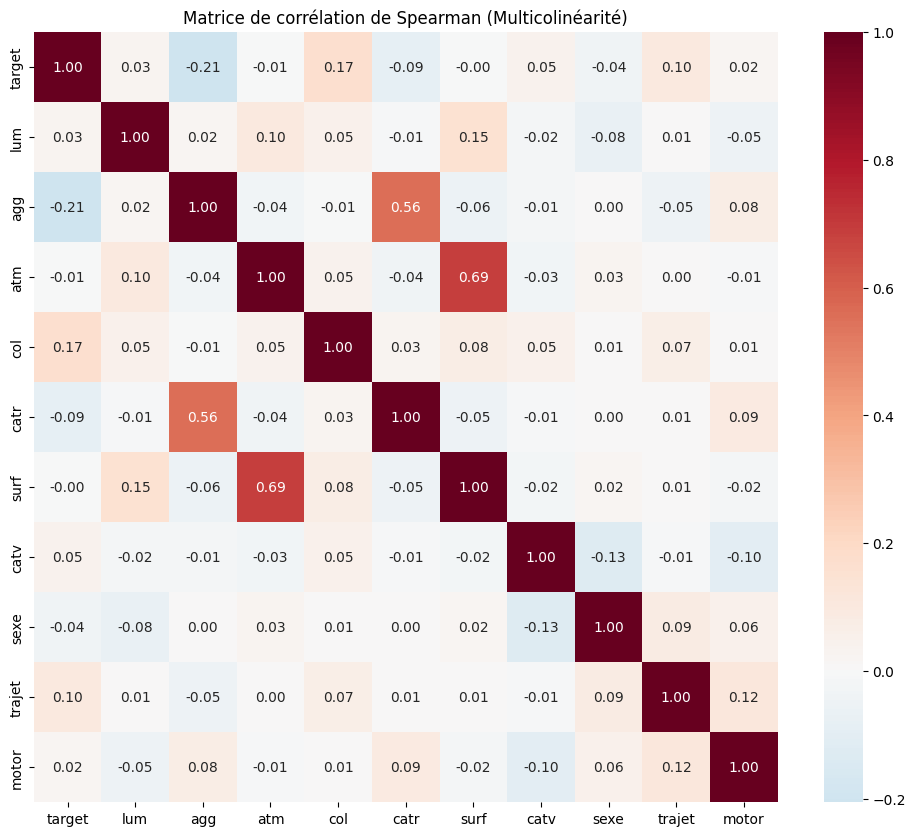

In [34]:
# On calcule la matrice de corrélation sur nos variables d'étude
corr_matrix = df[cols_etude].corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Matrice de corrélation de Spearman (Multicolinéarité)")
plt.show()

**Atmosphère (atm) et État de la surface (surf) :** Corrélation de 0.69.

**C'est logique :** s'il pleut (atm), la chaussée est généralement mouillée (surf).

**Risque :** Utiliser les deux simultanément dans le modèle pourrait créer de la redondance.

**Agglomération (agg) et Catégorie de route (catr) :** Corrélation de 0.56.

Une route en agglomération est souvent une voie communale, tandis qu'hors agglomération, on trouve les nationales/autoroutes.

- Relation avec la cible (target)

On observe que **agg** a la corrélation négative la plus marquée avec la gravité (**-0.21**). Cela confirme statistiquement qu'un accident en agglomération (vitesse plus faible) est souvent moins grave qu'un accident hors agglomération.

Les variables **col (0.17) et trajet (0.10)** montrent également des liens directs visibles sur la matrice.

**Étude de la Densité (Heatmap des Effectifs)**

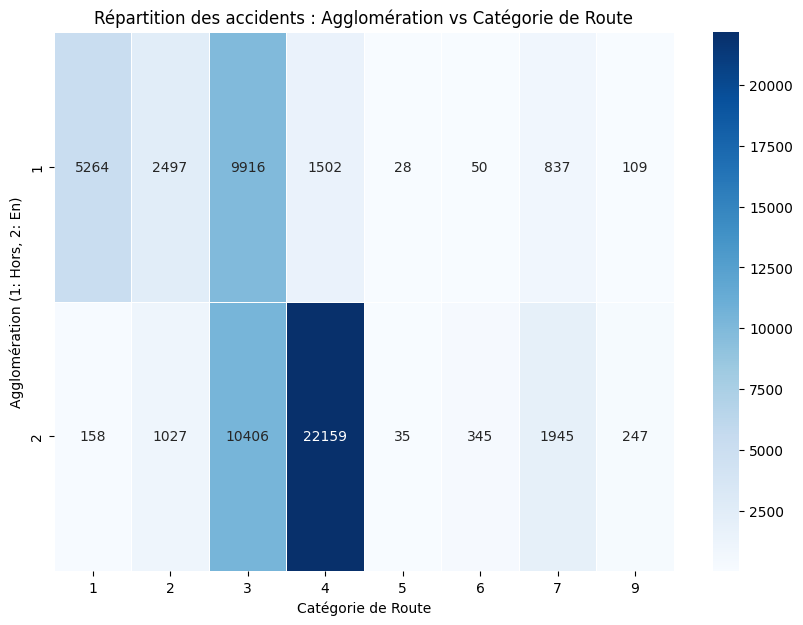

In [35]:
# Création de la table de contingence (les effectifs croisés)
# Ici on croise Agglomération et Catégorie de route
table_contingence = pd.crosstab(df['agg'], df['catr'])

# Affichage de la Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(table_contingence, 
            annot=True,      # Affiche les nombres dans les cases
            fmt="d",         # Format entier (pas de notation scientifique)
            cmap="Blues",    # Dégradé de bleu comme sur ton image
            linewidths=.5)   # Ajoute un petit filet entre les cases pour la lisibilité

plt.title("Répartition des accidents : Agglomération vs Catégorie de Route")
plt.ylabel("Agglomération (1: Hors, 2: En)")
plt.xlabel("Catégorie de Route")
plt.show()

**Commentaire :**

La matrice de corrélation de Spearman nous permet de détecter des redondances entre les variables :

**Couplage Environnemental :** Montre une forte corrélation entre **atm et surf (0.69)**. Cela confirme que l'état de la route est directement lié aux conditions météorologiques. Pour éviter la redondance dans le modèle économétrique, il faudra surveiller la stabilité des coefficients de ces deux variables.

**Structure de l'Infrastructure :** La corrélation entre **agg et catr (0.56)** est logique : les types de routes (**Autoroutes vs Voies communales**) sont fortement corrélés à la présence ou non en zone urbaine.

La variable **agg** présente la corrélation la plus forte avec la **target (−0.21)**, confirmant que les accidents hors agglomération sont statistiquement plus graves.

**Structure Factorielle (Cercle des Corrélations)**

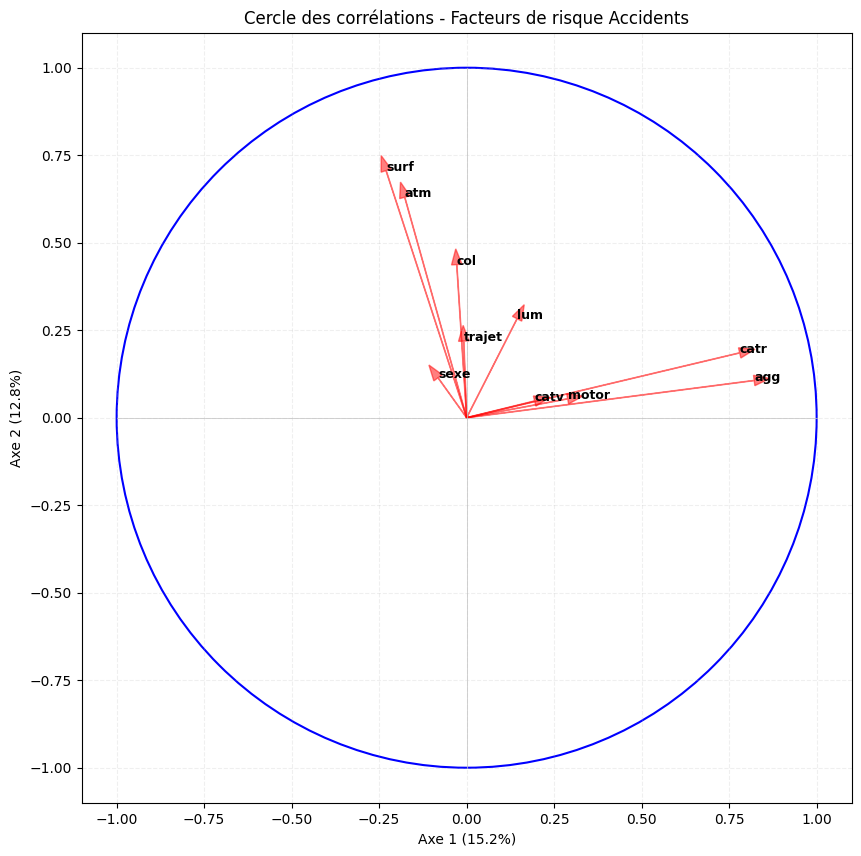

In [38]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Préparation des données (on ne garde que les colonnes numériques de ton étude)
# On exclut la target pour voir comment les variables explicatives se structurent entre elles
X = df[cols_etude].drop(columns=['target']).dropna()
quant_vars = X.columns
p = len(quant_vars)

# 2. Centrage et Réduction (Etape cruciale pour l'ACP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Calcul de l'ACP
pca = PCA(n_components=2)
pca.fit(X_scaled)

# 4. Calcul des coordonnées des variables (corrélations avec les axes)
# Coordonnées = Vecteurs propres * racine carrée des valeurs propres
corvar = pca.components_.T * np.sqrt(pca.explained_variance_)

# --- Ton code de visualisation adapté ---
fig, ax = plt.subplots(figsize=(10,10))

cercle = plt.Circle((0,0), 1, color='blue', fill=False, linewidth=1.5)
ax.add_artist(cercle)

plt.plot([-1,1],[0,0], color='silver', linewidth=0.5)
plt.plot([0,0],[-1,1], color='silver', linewidth=0.5)

# Tracé des flèches pour plus de clarté
for j in range(p):
    plt.arrow(0, 0, corvar[j, 0], corvar[j, 1], color='red', alpha=0.5, head_width=0.03)
    plt.annotate(quant_vars[j], (corvar[j, 0], corvar[j, 1]), fontsize=9, fontweight='bold')

plt.xlim(-1.1,1.1)
plt.ylim(-1.1,1.1)
plt.xlabel(f'Axe 1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'Axe 2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Cercle des corrélations - Facteurs de risque Accidents')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.2)
plt.show()

**Commentaire :**

- Hiérarchie et significativité des variables (**Test du χ² et V de Cramer**)

Les résultats du test du **χ²** montrent que toutes les variables analysées sont statistiquement significatives (**p-value ≈ 0.000**) pour expliquer la gravité des accidents.

Les variables les plus influentes sont **col (type de collision)**, **catv (catégorie de véhicule)** et **catr (catégorie de route)**, qui présentent les valeurs de V de Cramer les plus élevées (**V > 0.20**). Elles constituent donc les principaux facteurs associés à la gravité des accidents.

D'autres variables comme **sexe**, **motor** ou **atm (conditions météorologiques)** ont également une influence mais plus modérée sur la gravité.

- Analyse des corrélations et multicolinéarité

La matrice de corrélation de Spearman met en évidence certaines relations importantes entre variables.

On observe une forte corrélation entre **atm (météo)** et **surf (état de la surface)** (**ρ ≈ 0.69**), ce qui indique une redondance logique : de mauvaises conditions météorologiques entraînent souvent une chaussée dégradée ou glissante.

Une corrélation notable apparaît également entre **agg (agglomération)** et **catr (catégorie de route)** (**ρ ≈ 0.56**), suggérant que le type de route est fortement lié au contexte géographique (urbain ou rural).

Enfin, la corrélation négative entre **target** et **agg** (**-0.21**) indique que les accidents survenant hors agglomération sont généralement plus graves.

- Étude de la densité des accidents

L'analyse croisée entre **agglomération** et **catégorie de route** révèle une forte concentration des accidents sur les **voies communales en agglomération (catégorie 4)**, avec plus de **22 000** occurrences.

À l'inverse, les routes à vitesse plus élevée présentent moins d'accidents en volume, mais sont souvent associées à une gravité plus importante.

- Analyse du cercle des corrélations (ACP)

Le cercle des corrélations permet de visualiser les relations entre les variables en les projetant sur les deux premiers axes de l’ACP, qui expliquent environ **28 %** de la variabilité totale des données.

L’axe 1 semble représenter le **milieu et les infrastructures** (agglomération, type de route), tandis que l’axe 2 reflète davantage les **conditions de conduite**, notamment les variables climatiques.

On observe une forte corrélation entre **atm (conditions météorologiques)** et **surf (état de la surface)**, ce qui est cohérent : de mauvaises conditions météo entraînent souvent une chaussée dégradée ou glissante.

Certaines variables comme **catr**, **agg** ou **surf** sont bien représentées sur ce plan factoriel, ce qui indique qu’elles contribuent fortement à la structure des accidents dans le jeu de données.

Enfin, les variables orthogonales (**angle proche de 90°**) indiquent une relative indépendance entre certains facteurs, suggérant que certains types d’accidents peuvent survenir indépendamment des conditions météorologiques.

## Modélisation

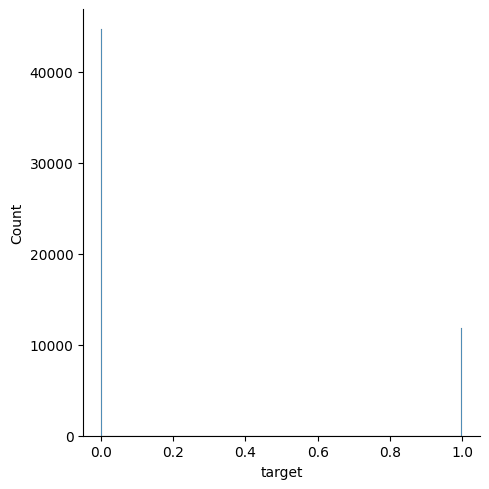

In [41]:
sns.displot(df['target'])

In [43]:
# 1. Sélection et Encodage
variables_finales = ['lum', 'agg', 'col', 'catr', 'vma', 'sexe', 'trajet', 'catv']
X = pd.get_dummies(df[variables_finales], drop_first=True).astype(float)
X = sm.add_constant(X) 
y = df['target']

# 2. Définition et Entraînement
logit_model = sm.GLM(y, X, family=sm.families.Binomial())
results = logit_model.fit() # On entraîne d'abord !

# 3. Affichage des Summary 1 et 2
print("="*25 + " SUMMARY 1 " + "="*25)
print(results.summary())

print("\n" + "="*25 + " SUMMARY 2 " + "="*25)
print(results.summary2())

# 4. Calcul et affichage des Odds Ratios (OR)
# On les présente souvent dans un petit DataFrame pour plus de clarté
odds_ratios = np.exp(results.params)
params = results.params
pvalues = results.pvalues

df_results = pd.DataFrame({
    'Coefficient': params,
    'Odds Ratio': odds_ratios,
    'P-value': pvalues
})

print("\n" + "="*25 + " INTERPRÉTATION (Odds Ratios) " + "="*25)
print(df_results.sort_values(by='Odds Ratio', ascending=False))

========================= SUMMARY 1 =========================
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:                56525
Model:                            GLM   Df Residuals:                    56516
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -26543.
Date:                Thu, 05 Mar 2026   Deviance:                       53085.
Time:                        17:42:10   Pearson chi2:                 5.77e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08351
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

**Analyse de la régression logistique**

Le modèle de régression logistique (GLM binomial) présente une performance globale correcte avec un AIC d’environ **53 103**. Il permet d’identifier les facteurs influençant la gravité des accidents à partir des **odds ratios (OR)**.

*Facteurs aggravants (OR > 1)*  
- **col (type de collision)** : facteur le plus influent, augmentant le risque de gravité d’environ **23 %** (OR ≈ 1.23).  
- **catr (catégorie de route)** : augmentation du risque d’environ **13 %** (OR ≈ 1.13).  
- **lum (luminosité)** : les conditions de faible luminosité augmentent légèrement le risque de gravité.

*Facteurs protecteurs (OR < 1)*  
- **agg (agglomération)** : OR ≈ 0.29, indiquant que les accidents en agglomération sont **moins susceptibles d’être graves**, probablement en raison de vitesses plus faibles et d’un accès plus rapide aux secours.

*Variables peu ou non significatives*  
- **sexe** présente un effet faible avec une p-value proche du seuil de significativité.  
- **vma (vitesse maximale autorisée)** n’apparaît pas comme un prédicteur significatif dans ce modèle lorsque d’autres variables comme l’agglomération et la catégorie de route sont prises en compte.

In [47]:
# 1. Sélection des variables significatives
variables_finales_opti = ['lum', 'agg', 'col', 'catr', 'trajet', 'catv']

# 2. Préparation des données (X_opti)
X_opti = pd.get_dummies(df[variables_finales_opti], drop_first=True).astype(float)
X_opti = sm.add_constant(X_opti)
y = df['target']

# 3. Définition et Entraînement (sur X_opti cette fois !)
logit_model_opti = sm.GLM(y, X_opti, family=sm.families.Binomial())
results_opti = logit_model_opti.fit()

# 4. Affichage des résumés
print("="*25 + " SUMMARY 1 " + "="*25)
print(results_opti.summary())

print("\n" + "="*25 + " SUMMARY 2 " + "="*25)
print(results_opti.summary2())

# 5. Calcul des Odds Ratios et présentation propre
df_results = pd.DataFrame({
    'Coefficient': results_opti.params,
    'Odds Ratio': np.exp(results_opti.params),
    'P-value': results_opti.pvalues
})

print("\n" + "="*25 + " INTERPRÉTATION (Odds Ratios) " + "="*25)
# On trie par Odds Ratio pour voir les facteurs les plus aggravants en premier
print(df_results.sort_values(by='Odds Ratio', ascending=False))

========================= SUMMARY 1 =========================
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:                56525
Model:                            GLM   Df Residuals:                    56518
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -26544.
Date:                Thu, 05 Mar 2026   Deviance:                       53089.
Time:                        17:54:11   Pearson chi2:                 5.77e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08346
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

Le modèle de régression logistique montre une **significativité globale parfaite** pour les variables restantes (**lum, agg, col, catr, trajet, catv**) avec toutes les **p-values ≈ 0.000**.  

**Amélioration de l’AIC** : passage de **53 103,3 à 53 102,7**, indiquant une simplification du modèle sans perte de capacité explicative (principe de parsimonie).

**Pseudo R² (Cox & Snell)** : **0.083**, montre la cohérence pour des données réelles d’accidents.

**Milieu urbain comme bouclier** : un accident en agglomération a ~**3,4** fois moins de chances d’être grave (**1/0.29 ≈ 3.4**). le type de collision et la catégorie de route sont les principaux facteurs aggravants.

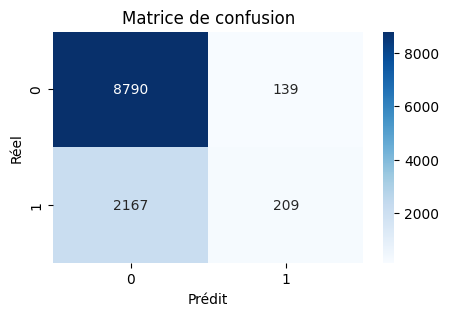

In [64]:
y_pred = results.predict(X_test)

y_pred_class = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_class)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()

## Classification de la Gravité 

On ajoute **age_usager**, **vma et nbv** pour apporter une profondeur multidimensionnelle pour :

- Augmenter la complétude du modèle : Un accident n'est jamais dû qu'à un seul facteur. En ajoutant l'humain (**age_usager**), la vitesse (**vma**) et l'infrastructure (**nbv**), on couvre les 3 piliers de la sécurité routière (**Homme / Véhicule / Réseau**).

- Réduire le biais : Si on ignores **l'âge**, le modèle pourrait attribuer une gravité élevée à une "petite collision en ville" simplement parce que la victime était fragile. Donc **l'âge** permet de "corriger" cette erreur d'interprétation du modèle.

Optimization terminated successfully.
         Current function value: 0.466270
         Iterations 6
==================== RÉSULTATS DU MODÈLE ====================
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                44173
Model:                          Logit   Df Residuals:                    44159
Method:                           MLE   Df Model:                           13
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                  0.1028
Time:                        21:31:27   Log-Likelihood:                -20597.
converged:                       True   LL-Null:                       -22956.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7569      0.077     -9.781   

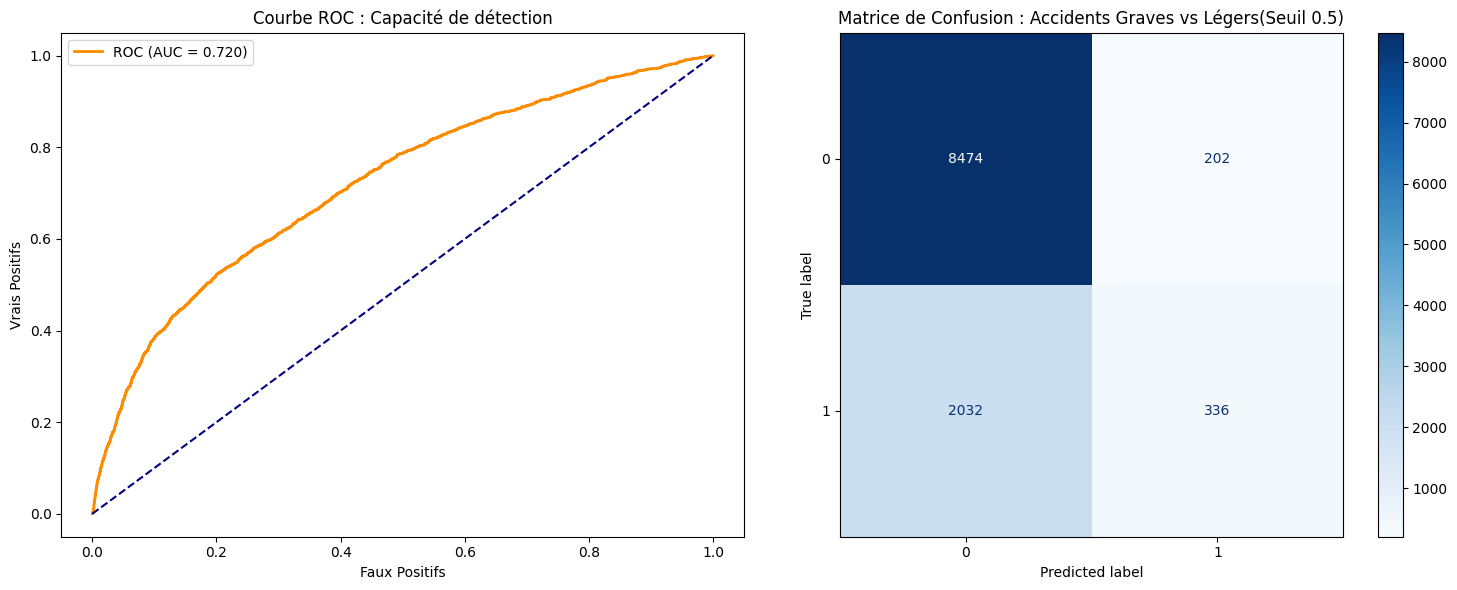

In [73]:
# --- 1. Préparation et Enrichissement ---
df_class = df.copy()

# Création de la variable Age (Indispensable pour la précision)
df_class['age_usager'] = df_class['an'] - df_class['an_nais']

# Sélection des 13 variables (Ton set initial + les 3 ajouts stratégiques)
variables_num = ['vma', 'age_usager', 'nbv']
variables_qual = ['lum', 'agg', 'atm', 'col', 'catr', 'surf', 'sexe', 'trajet', 'catv', 'motor']

# Nettoyage des valeurs manquantes pour le modèle
df_class = df_class[variables_num + variables_qual + ['target']].dropna()

# --- 2. Encodage et Standardisation ---
X = pd.get_dummies(df_class[variables_num + variables_qual], drop_first=True).astype(float)

# On centre-réduit les variables numériques pour qu'elles soient comparables
scaler = StandardScaler()
X[variables_num] = scaler.fit_transform(X[variables_num])

X = sm.add_constant(X) # Ajout de l'intercept
y = df_class['target']

# --- 3. Découpage Stratifié ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Entraînement du Modèle ---
logit_model = sm.Logit(y_train, X_train)
results = logit_model.fit()

# --- 5. Prédictions et Seuils ---
y_prob = results.predict(X_test)
y_pred = (y_prob > 0.5).astype(int) # Seuil standard à 0.5

# --- 6. Affichage des Résultats ---
print("="*20 + " RÉSULTATS DU MODÈLE " + "="*20)
print(results.summary())
print(results.summary2())

print("\n" + "="*20 + " RAPPORT DE PERFORMANCE " + "="*20)
print(classification_report(y_test, y_pred))
print(f"Score AUC-ROC final : {roc_auc_score(y_test, y_prob):.4f}")

# --- 7. Visualisations ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc(fpr, tpr):.3f})')
ax1.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax1.set_title('Courbe ROC : Capacité de détection')
ax1.set_xlabel('Faux Positifs')
ax1.set_ylabel('Vrais Positifs')
ax1.legend()

# Matrice de Confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=ax2)
ax2.set_title('Matrice de Confusion : Accidents Graves vs Légers(Seuil 0.5)')

plt.tight_layout()
plt.show()

Suppression des variables **atm** (météo) et **surf** (état de la surface), tu élimines le "bruit" du modèle.

Optimization terminated successfully.
         Current function value: 0.466275
         Iterations 6
==================== RÉSULTATS MODÈLE ÉPURÉ ====================
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                44173
Model:                          Logit   Df Residuals:                    44161
Method:                           MLE   Df Model:                           11
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                  0.1028
Time:                        21:43:44   Log-Likelihood:                -20597.
converged:                       True   LL-Null:                       -22956.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7618      0.075    -10.119

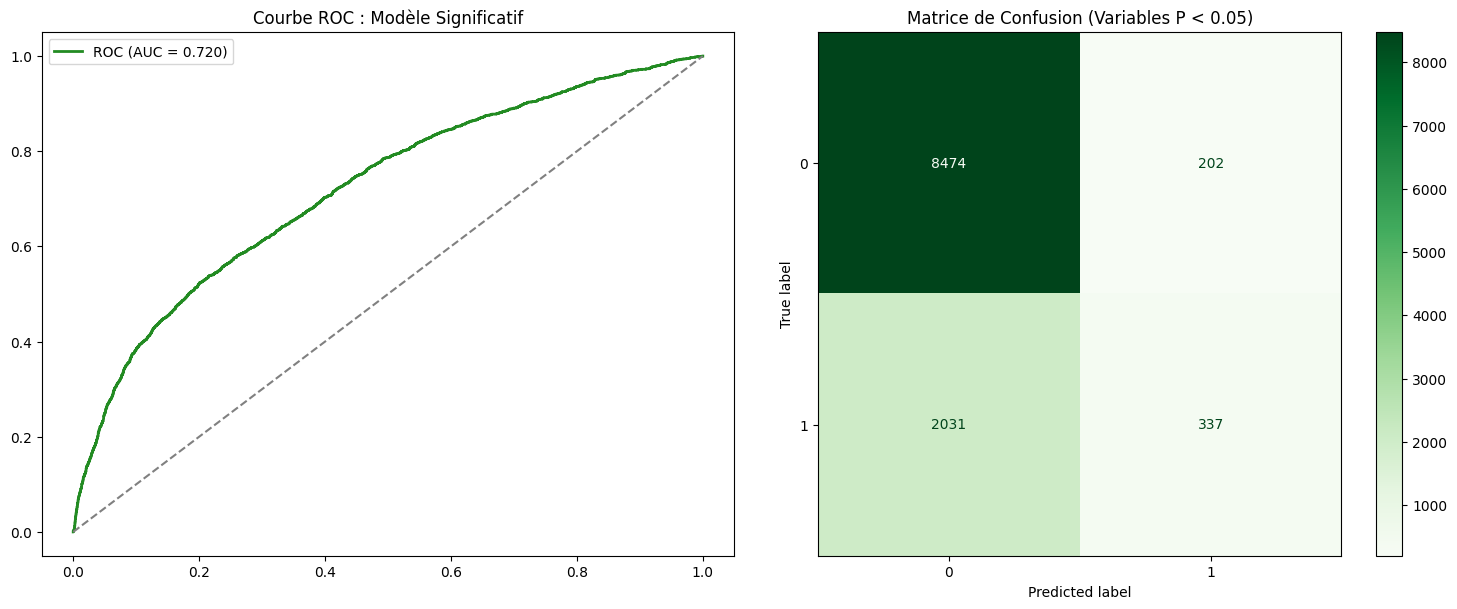

In [75]:
# --- 1. Préparation ---
df_final = df.copy()
df_final['age_usager'] = df_final['an'] - df_final['an_nais']

# Sélection des variables SIGNIFICATIVES (P-value < 0.05)
variables_num = ['vma', 'age_usager', 'nbv']
variables_qual = ['lum', 'agg', 'col', 'catr', 'sexe', 'trajet', 'catv', 'motor']

# Nettoyage
df_final = df_final[variables_num + variables_qual + ['target']].dropna()

# --- 2. Encodage et Standardisation ---
X = pd.get_dummies(df_final[variables_num + variables_qual], drop_first=True).astype(float)

scaler = StandardScaler()
X[variables_num] = scaler.fit_transform(X[variables_num])

X = sm.add_constant(X)
y = df_final['target']

# --- 3. Découpage Stratifié (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 4. Entraînement ---
logit_final = sm.Logit(y_train, X_train)
results_final = logit_final.fit()

# --- 5. Prédictions ---
y_prob = results_final.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

# --- 6. Affichage des résultats ---
print("="*20 + " RÉSULTATS MODÈLE ÉPURÉ " + "="*20)
print(results_final.summary())
print(results_final.summary2())
print("\n" + "="*20 + " RAPPORT DE PERFORMANCE " + "="*20)
print(classification_report(y_test, y_pred))

# --- 7. Graphiques ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr, tpr, color='forestgreen', lw=2, label=f'ROC (AUC = {auc(fpr, tpr):.3f})')
ax1.plot([0, 1], [0, 1], color='grey', linestyle='--')
ax1.set_title('Courbe ROC : Modèle Significatif')
ax1.legend()

# Matrice de Confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Greens', ax=ax2)
ax2.set_title('Matrice de Confusion (Variables P < 0.05)')

plt.tight_layout()
plt.show()

**Commentaire :**

L’ajout de variables stratégiques (**âge de l’usager, vitesse maximale autorisée, nombre de voies**) a permis d’améliorer la capacité prédictive du modèle.

*Capacité de discrimination (Courbe ROC)*

Le score **AUC-ROC atteint 0.72**, cela montre que l’intégration de variables humaines et d’infrastructure améliore la capacité du modèle à distinguer les accidents graves des accidents légers.

*Matrice de confusion :* Sur un échantillon de test de **11 044 observations** :

**Accidents graves (classe 1)** : 336 cas correctement détectés.  
**Accidents légers (classe 0)** : 8 474 vrais négatifs, confirmant une très bonne spécificité.

*Métriques de performance*

**Accuracy : 80 %** — performance globale stable.  
**Recall (classe 1) : 14 %** — amélioration notable par rapport au premier modèle (9 %).  
**Precision (classe 1) : 62 %** — la majorité des prédictions d’accidents graves sont correctes.

Le modèle présente de **meilleures performances globales**. Donc l’**AIC (41 217)** confirme que l’ajout des variables **age_usager, vma et nbv** améliore significativement la qualité statistique du modèle.